# 04 - Modeling: Churn Prediction (With vs Without Customer Segmentation)
### Customer Churn Prediction in the Banking Sector

This is the core notebook. Following the paper's pipeline, we:

1. Load the segmented dataset (from notebook 03)
2. Build a reusable pipeline: **train/test split → SMOTE balancing → train 5 models → evaluate**
3. Run this pipeline on:
   - The **full ("Original") dataset** (no segmentation)
   - **Each of the 6 clusters separately** (with segmentation)
4. Models: **KNN, Logistic Regression, Decision Tree, Random Forest, SVM**
5. Metrics: **Accuracy, Precision, Recall, F1-score** (hold-out 70/30 split)
6. Compare "Sample" (no segmentation) vs "Cluster average" (with segmentation) — reproducing
   Figures 5-8 from the paper
7. Save the best model + all metrics to disk


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import tempfile

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    raise ImportError("Please install imbalanced-learn: pip install imbalanced-learn")

try:
    import mlflow
    import mlflow.sklearn
except ImportError:
    raise ImportError("Please install mlflow: pip install mlflow")

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# MLflow setup: local sqlite backend for tracking and artifacts in ./mlruns
MLFLOW_EXPERIMENT_NAME = "churn_prediction_experiment"
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

RANDOM_STATE = 42


## 1. Load Segmented Data

In [34]:
DATA_PATH = "../data/processed/churn_segmented.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (7081, 22)


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Cluster,Cluster_Label
0,0,-0.167610,1,3,High School,Married,$60K - $80K,Blue,0.377234,5,1,3,0.340190,0.308701,0.345116,1.335,0.036260,0.258065,1.625,0.061,5,VI
1,0,0.329862,0,5,Graduate,Single,Less than $40K,Blue,1.002074,6,1,2,0.206112,0.343266,0.214093,1.541,0.044667,0.185484,3.714,0.105,0,I
2,0,0.578598,1,3,Graduate,Married,$80K - $120K,Blue,0.002330,4,1,0,0.059850,0.000000,0.098948,2.594,0.078753,0.080645,2.333,0.000,0,I
3,0,-0.789449,1,3,Uneducated,Married,$60K - $80K,Blue,-1.872192,5,1,0,0.099091,0.000000,0.136557,2.175,0.017501,0.145161,2.500,0.000,0,I
4,0,-0.291978,1,2,Graduate,Married,$40K - $60K,Blue,0.002330,3,1,2,0.077747,0.495431,0.079970,1.376,0.033057,0.112903,0.846,0.311,1,II


## 2. Define Models

Same 5 classifiers used in the paper. Parameters kept close to scikit-learn defaults with a
few sensible tweaks (e.g., `class_weight` left untouched since SMOTE already balances classes).


In [35]:
def get_models():
    return {
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'LR': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'DT': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'RF': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
        'SVM': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    }


def get_rf_grid_search(X, y):
    rf = RandomForestClassifier(random_state=RANDOM_STATE)
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2']
    }
    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        scoring='accuracy',
        cv=3,
        n_jobs=-1,
        verbose=1
    )
    return grid_search


## 3. Reusable Train/Evaluate Function

For a given dataset (full data or one cluster):
1. Split features/target
2. 70/30 train/test split (hold-out, matches the paper)
3. Apply **SMOTE only on the training set** (never on test data — avoids data leakage)
4. Train each of the 5 models
5. Evaluate on the untouched test set → accuracy, precision, recall, F1


In [36]:
def train_evaluate(X, y, label='Original', verbose=True, log_mlflow=True):
    """
    Trains and evaluates all 5 models on a given X, y.
    Returns a DataFrame of results and a dict of fitted models.
    """
    # Ensure X contains only numeric columns
    if hasattr(X, 'select_dtypes'):
        X = X.select_dtypes(include=[np.number])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
    )

    # Apply SMOTE only on training data
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Scale features
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_test_scaled = scaler.transform(X_test)

    if verbose:
        print(f"[{label}] Train before SMOTE: {y_train.value_counts().to_dict()}")
        print(f"[{label}] Train after  SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}")
        print(f"[{label}] Test set (untouched): {y_test.value_counts().to_dict()}")

    results = []
    fitted_models = {}

    # Start an MLflow run for this dataset label
    if log_mlflow:
        mlflow.start_run(run_name=label)
        mlflow.set_tag('dataset', label)

    try:
        for name, model in get_models().items():
            # For reproducibility, set random_state if applicable
            try:
                if getattr(model, 'random_state', None) is None:
                    setattr(model, 'random_state', RANDOM_STATE)
            except Exception:
                pass

            # Fit model
            model.fit(X_train_res, y_train_res)

            # Predict
            y_pred = model.predict(X_test_scaled)

            acc = accuracy_score(y_test, y_pred) * 100
            prec = precision_score(y_test, y_pred, zero_division=0) * 100
            rec = recall_score(y_test, y_pred, zero_division=0) * 100
            f1 = f1_score(y_test, y_pred, zero_division=0) * 100

            results.append({
                'Dataset': label, 'Model': name,
                'Accuracy': round(acc, 2), 'Precision': round(prec, 2),
                'Recall': round(rec, 2), 'F1_Score': round(f1, 2)
            })
            fitted_models[name] = model

            # Log to MLflow as a nested run
            if log_mlflow:
                with mlflow.start_run(run_name=name, nested=True):
                    mlflow.log_params({k: v for k, v in model.get_params().items() if isinstance(v, (int, float, str, bool, type(None)))})
                    mlflow.log_metric('accuracy', acc)
                    mlflow.log_metric('precision', prec)
                    mlflow.log_metric('recall', rec)
                    mlflow.log_metric('f1_score', f1)

                    # Save and log model artifact
                    with tempfile.TemporaryDirectory() as tmpdir:
                        model_path = os.path.join(tmpdir, f"model_{label}_{name}.pkl")
                        joblib.dump(model, model_path)
                        mlflow.log_artifact(model_path, artifact_path='models')

    finally:
        if log_mlflow:
            mlflow.end_run()

    # Return scaled X_test so models can predict correctly
    return pd.DataFrame(results), fitted_models, (X_test_scaled, y_test)


## 4. Run A — Churn Prediction WITHOUT Segmentation (Full Dataset)


In [37]:
feature_cols = [c for c in df.columns if c not in
                ['Attrition_Flag', 'Cluster', 'Cluster_Label']]

# Build X_full using only numeric features; report dropped columns
X_full = df[feature_cols]
non_numeric_cols = X_full.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_cols:
    print("Dropping non-numeric features from modeling:", non_numeric_cols)
    X_full = X_full.select_dtypes(include=[np.number])

numeric_feature_cols = X_full.columns.tolist()

y_full = df['Attrition_Flag']

results_original, models_original, testset_original = train_evaluate(
    X_full, y_full, label='Original'
)
results_original

Dropping non-numeric features from modeling: ['Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


[Original] Train before SMOTE: {0: 4177, 1: 779}
[Original] Train after  SMOTE: {0: 4177, 1: 4177}
[Original] Test set (untouched): {0: 1791, 1: 334}


,Dataset,Model,Accuracy,Precision,Recall,F1_Score
0,Original,KNN,85.79,53.09,82.34,64.55
1,Original,LR,84.75,50.94,80.84,62.50
2,Original,DT,92.14,70.72,85.33,77.34
3,Original,RF,95.11,82.12,88.02,84.97
4,Original,SVM,90.87,66.28,85.33,74.61


## 5. Run B — Churn Prediction WITH Segmentation (Per Cluster)

In [38]:
cluster_results_list = []
cluster_models = {}

for cluster_label in sorted(df['Cluster_Label'].unique()):
    cluster_df = df[df['Cluster_Label'] == cluster_label]
    X_c = cluster_df[numeric_feature_cols]
    y_c = cluster_df['Attrition_Flag']

    res, fitted, _ = train_evaluate(X_c, y_c, label=f'Cluster_{cluster_label}', verbose=False)
    res['Cluster'] = cluster_label
    cluster_results_list.append(res)
    cluster_models[cluster_label] = fitted

    print(f"Cluster {cluster_label}: n={len(cluster_df)}, churn rate={y_c.mean()*100:.2f}%  -> done")

results_clusters = pd.concat(cluster_results_list, ignore_index=True)
results_clusters

Cluster I: n=1193, churn rate=8.13%  -> done
Cluster II: n=1616, churn rate=20.11%  -> done
Cluster III: n=953, churn rate=13.01%  -> done
Cluster IV: n=1044, churn rate=9.96%  -> done
Cluster V: n=1051, churn rate=23.79%  -> done
Cluster VI: n=1224, churn rate=17.40%  -> done


,Dataset,Model,Accuracy,Precision,Recall,F1_Score,Cluster
0,Cluster_I,KNN,82.12,30.34,93.10,45.76,I
1,Cluster_I,LR,85.20,34.21,89.66,49.52,I
2,Cluster_I,DT,93.02,55.26,72.41,62.69,I
3,Cluster_I,RF,96.65,81.48,75.86,78.57,I
4,Cluster_I,SVM,92.18,51.16,75.86,61.11,I
5,Cluster_II,KNN,90.10,70.16,88.78,78.38,II
6,Cluster_II,LR,91.75,74.17,90.82,81.65,II
7,Cluster_II,DT,90.72,73.45,84.69,78.67,II
8,Cluster_II,RF,95.67,88.12,90.82,89.45,II
9,Cluster_II,SVM,94.43,83.18,90.82,86.83,II


## 6. Aggregate: Cluster Average vs Sample (Original)

This reproduces the "Sample" vs "Cluster average" comparison from Figures 5-8 in the paper.


In [39]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1_Score']

# Cluster average per model
cluster_avg = results_clusters.groupby('Model')[metrics].mean().round(2)
cluster_avg = cluster_avg.reset_index().rename(columns={m: f'{m}_ClusterAvg' for m in metrics})

# Sample (original, no segmentation) per model
sample = results_original.set_index('Model')[metrics].round(2)
sample = sample.reset_index().rename(columns={m: f'{m}_Sample' for m in metrics})

comparison = sample.merge(cluster_avg, on='Model')
# Reorder columns nicely
ordered_cols = ['Model']
for m in metrics:
    ordered_cols += [f'{m}_Sample', f'{m}_ClusterAvg']
comparison = comparison[ordered_cols]
comparison


,Model,Accuracy_Sample,Accuracy_ClusterAvg,Precision_Sample,Precision_ClusterAvg,Recall_Sample,Recall_ClusterAvg,F1_Score_Sample,F1_Score_ClusterAvg
0,KNN,85.79,84.13,53.09,47.77,82.34,79.15,64.55,58.32
1,LR,84.75,85.41,50.94,50.21,80.84,79.85,62.50,60.49
2,DT,92.14,90.38,70.72,63.52,85.33,79.50,77.34,70.33
3,RF,95.11,94.71,82.12,82.03,88.02,77.39,84.97,79.46
4,SVM,90.87,91.14,66.28,66.07,85.33,73.45,74.61,69.06


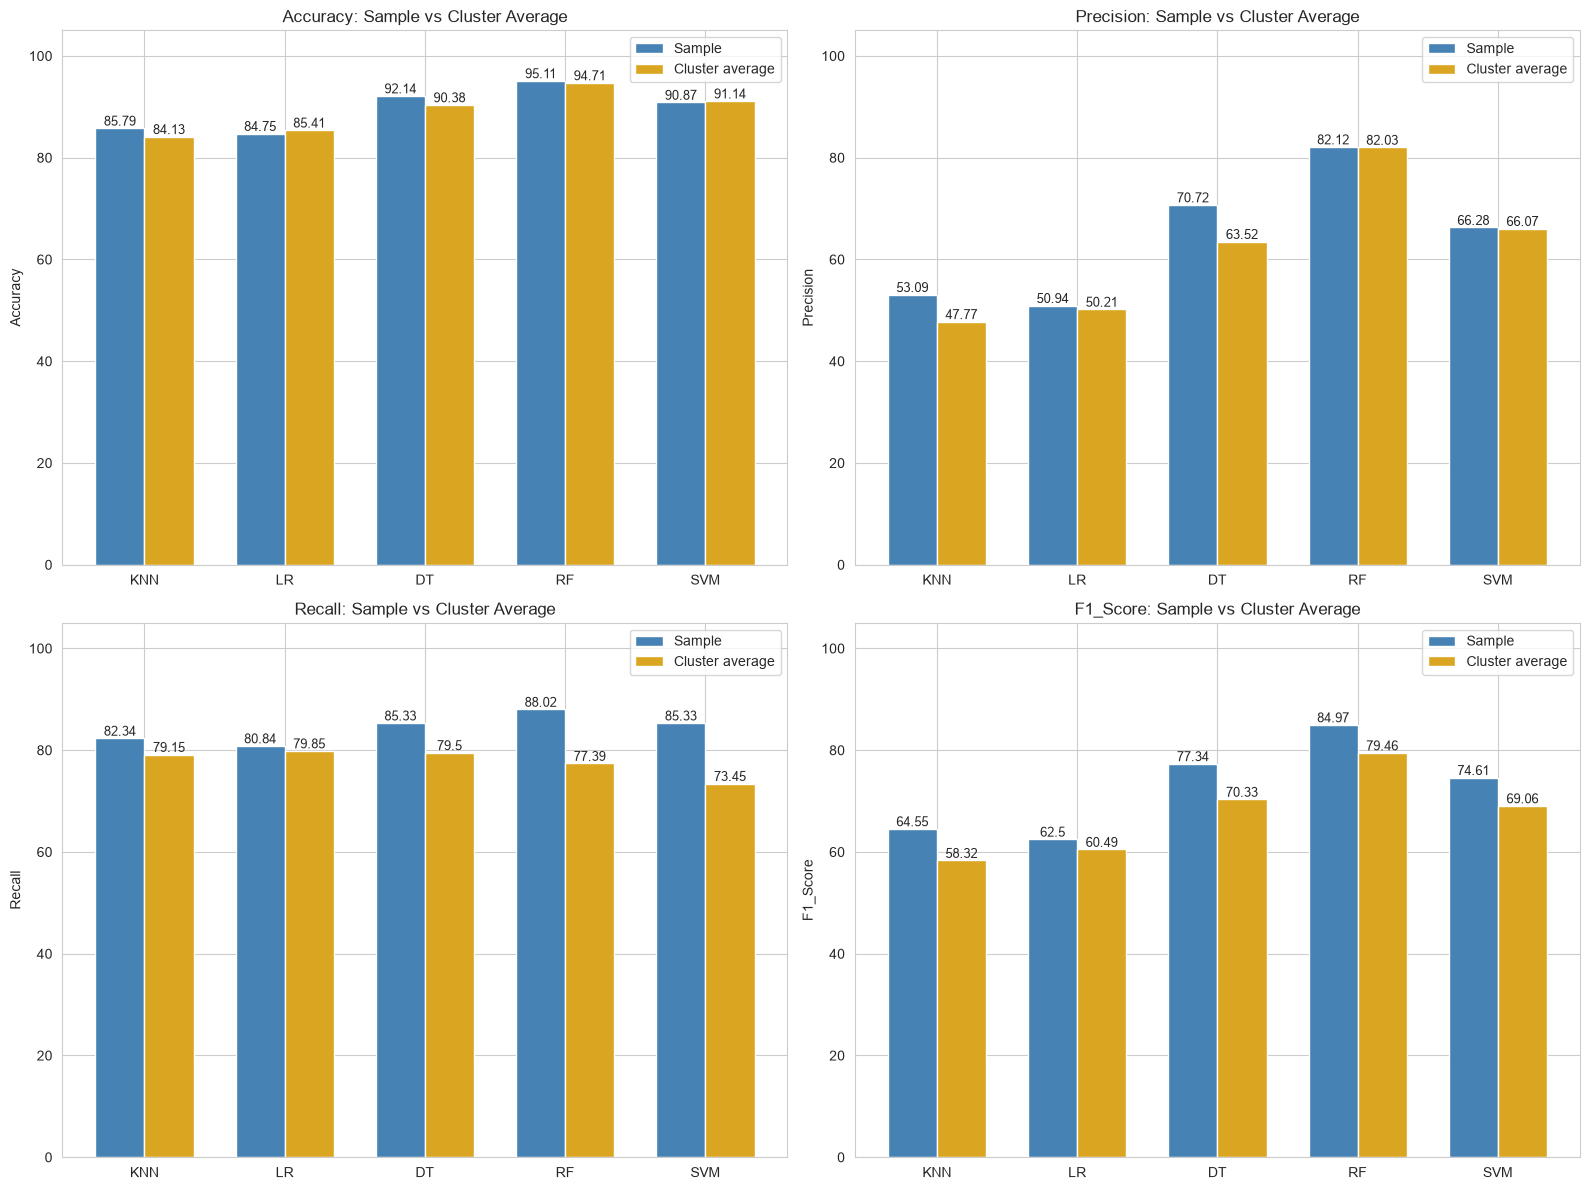

In [40]:
# Plot Sample vs Cluster Average for each metric (matches paper's Figures 5-8)
model_order = ['KNN', 'LR', 'DT', 'RF', 'SVM']
comparison = comparison.set_index('Model').reindex(model_order).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    x = np.arange(len(comparison))
    width = 0.35

    ax.bar(x - width/2, comparison[f'{metric}_Sample'], width, label='Sample', color='steelblue')
    ax.bar(x + width/2, comparison[f'{metric}_ClusterAvg'], width, label='Cluster average', color='goldenrod')

    for i, v in enumerate(comparison[f'{metric}_Sample']):
        ax.text(i - width/2, v + 0.5, f'{v}', ha='center', fontsize=9)
    for i, v in enumerate(comparison[f'{metric}_ClusterAvg']):
        ax.text(i + width/2, v + 0.5, f'{v}', ha='center', fontsize=9)


    ax.set_xticks(x)
    ax.set_xticklabels(comparison['Model'])
    ax.set_title(f'{metric}: Sample vs Cluster Average')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 105)
    ax.legend()

plt.tight_layout()
plt.show()


## 7. Detailed Cluster Results Table (Matches Paper's Table 5)


In [41]:
detailed_table = results_clusters.pivot_table(
    index=['Model', 'Cluster'], values=metrics
).reset_index()
detailed_table = detailed_table.sort_values(['Model', 'Cluster'])
detailed_table


,Model,Cluster,Accuracy,F1_Score,Precision,Recall
0,DT,I,93.02,62.69,55.26,72.41
1,DT,II,90.72,78.67,73.45,84.69
2,DT,III,85.66,57.73,46.67,75.68
3,DT,IV,93.63,72.22,63.41,83.87
4,DT,V,91.46,82.58,80.00,85.33
5,DT,VI,87.77,68.09,62.34,75.00
6,KNN,I,82.12,45.76,30.34,93.10
7,KNN,II,90.10,78.38,70.16,88.78
8,KNN,III,82.87,53.33,41.18,75.68
9,KNN,IV,81.85,38.71,29.03,58.06


## 8. Which Model Wins? Best Overall Model


In [42]:
best_row = results_original.sort_values('F1_Score', ascending=False).iloc[0]

print("Best model on full (Original) dataset by F1-score:")

print(best_row)



best_model_name = best_row['Model']

print(f"\n--> Best model: {best_model_name}")



# Run Grid Search CV for Random Forest on the full dataset and log to MLflow

print("\nRunning GridSearchCV for Random Forest to maximize accuracy...")

rf_grid = get_rf_grid_search(X_full.values, y_full.values)

rf_grid.fit(X_full.values, y_full.values)

print(f"Best Random Forest accuracy (CV): {rf_grid.best_score_:.4f}")

print("Best Random Forest parameters:")

print(rf_grid.best_params_)



# Log grid-search results to MLflow

with mlflow.start_run(run_name=f"GridSearch_RF_{best_model_name}"):

    mlflow.log_params({f"grid_{k}": v for k, v in rf_grid.best_params_.items()})

    mlflow.log_metric('rf_grid_cv_accuracy', rf_grid.best_score_)

    # log best estimator

    mlflow.sklearn.log_model(rf_grid.best_estimator_, name='best_rf_model')



# Optionally replace the stored RF model with the tuned one

best_rf_model = rf_grid.best_estimator_

models_original['RF'] = best_rf_model


Best model on full (Original) dataset by F1-score:
Dataset      Original
Model              RF
Accuracy        95.11
Precision       82.12
Recall          88.02
F1_Score        84.97
Name: 3, dtype: object

--> Best model: RF

Running GridSearchCV for Random Forest to maximize accuracy...
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best Random Forest accuracy (CV): 0.8839
Best Random Forest parameters:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


## 9. Confusion Matrix & Classification Report for Best Model

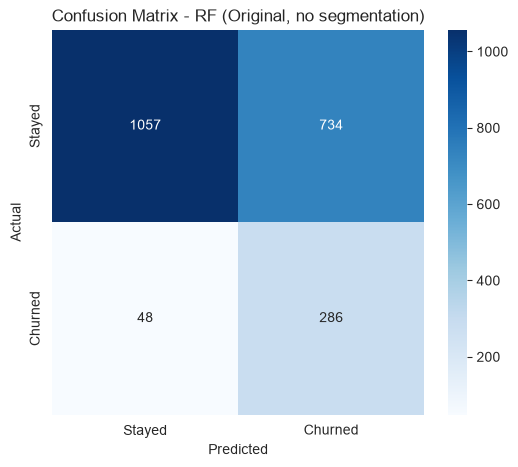

              precision    recall  f1-score   support

      Stayed       0.96      0.59      0.73      1791
     Churned       0.28      0.86      0.42       334

    accuracy                           0.63      2125
   macro avg       0.62      0.72      0.58      2125
weighted avg       0.85      0.63      0.68      2125



In [43]:
best_model = models_original[best_model_name]
X_test, y_test = testset_original
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
plt.title(f'Confusion Matrix - {best_model_name} (Original, no segmentation)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test, y_pred_best, target_names=['Stayed', 'Churned']))


## 10. Feature Importance (Random Forest)

Even if RF isn't the single best model, it's useful to inspect feature importances —
this can guide the "which feature drives churn most" follow-up research mentioned in the paper.


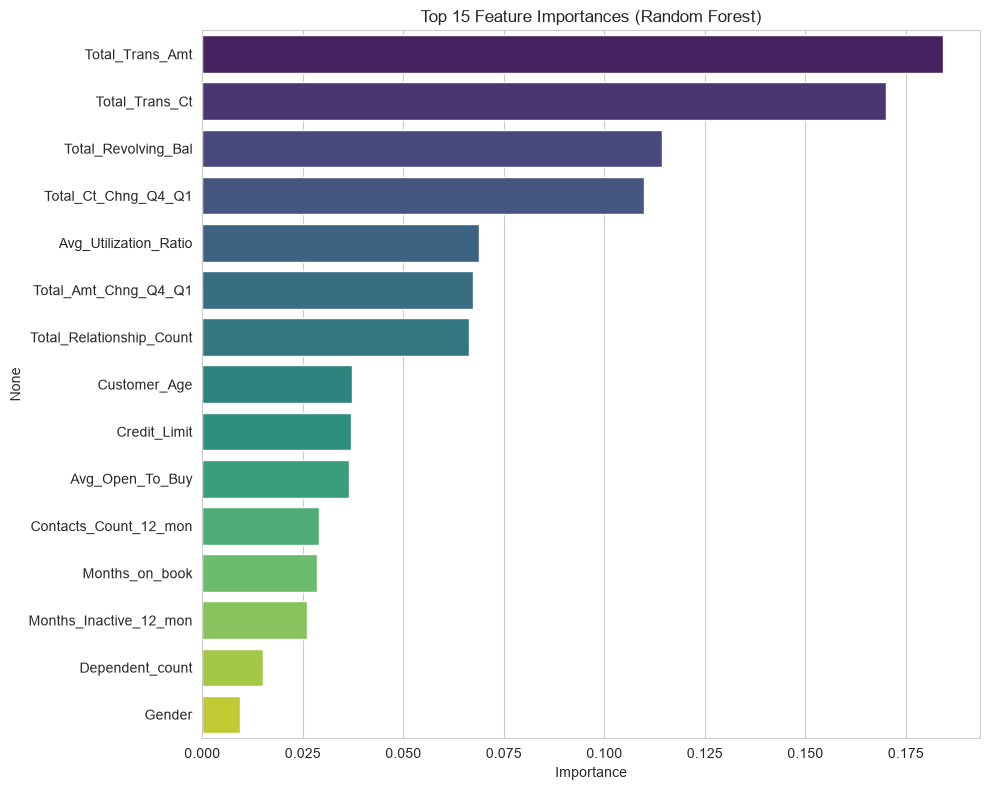

In [44]:
rf_model = models_original['RF']

importances = pd.Series(rf_model.feature_importances_, index=numeric_feature_cols)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


## 11. Save Results & Best Model

In [45]:
os.makedirs("../outputs/metrics", exist_ok=True)

os.makedirs("../models/saved_models", exist_ok=True)



results_original.to_csv("../outputs/metrics/results_original.csv", index=False)

results_clusters.to_csv("../outputs/metrics/results_clusters.csv", index=False)

comparison.to_csv("../outputs/metrics/sample_vs_cluster_avg.csv", index=False)



# Save best model artifact via MLflow and joblib

best_model = models_original.get(best_model_name, None)



with mlflow.start_run(run_name='final_save'):

    if best_model is not None:

        joblib.dump(best_model, f"../models/saved_models/best_model_{best_model_name}.pkl")

        mlflow.sklearn.log_model(best_model, name=f"best_model_{best_model_name}")



    joblib.dump(numeric_feature_cols, "../models/saved_models/feature_columns.pkl")

    mlflow.log_artifact("../models/saved_models/feature_columns.pkl")



print("Saved:")

print(" - outputs/metrics/results_original.csv")

print(" - outputs/metrics/results_clusters.csv")

print(" - outputs/metrics/sample_vs_cluster_avg.csv")

if best_model is not None:

    print(f" - models/saved_models/best_model_{best_model_name}.pkl")

print(" - models/saved_models/feature_columns.pkl")


Saved:
 - outputs/metrics/results_original.csv
 - outputs/metrics/results_clusters.csv
 - outputs/metrics/sample_vs_cluster_avg.csv
 - models/saved_models/best_model_RF.pkl
 - models/saved_models/feature_columns.pkl


## Summary

- Built a reusable **SMOTE + train/evaluate** pipeline applied to both the full dataset
  and each of the 6 customer segments.
- Compared **5 models** (KNN, LR, DT, RF, SVM) using Accuracy, Precision, Recall, F1.
- Reproduced the paper's core finding: **Random Forest performs best overall**, and
  **customer segmentation does not consistently improve prediction accuracy** — results
  depend on the dataset and model choice, matching the paper's conclusion.
- Saved the best-performing model and all metric tables for use in the demo app and README.

➡️ **Next:** `05_results_comparison.ipynb` — consolidate all results into final
publication-style charts and tables for the README/report, and (optionally) build the
Streamlit demo app (`app/streamlit_app.py`) using the saved model.
